In [214]:
# Importação das bibliotecas

# pandas: utilizado para carregar, organizar e analisar os dados.
import pandas as pd

# numpy: utilizado para operações numéricas e transformações matemáticas.
import numpy as np

# matplotlib: utilizado para criar gráficos.
import matplotlib.pyplot as plt

# seaborn: utilizado para criar visualizações estatísticas.
import seaborn as sns

# StandardScaler: utilizado para padronizar as variáveis antes do K-Means.
from sklearn.preprocessing import StandardScaler

# KMeans: algoritmo de agrupamento utilizado para segmentar os clientes.
from sklearn.cluster import KMeans

# Métricas utilizadas para avaliar a qualidade dos agrupamentos.
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Permite visualizar todas as colunas das tabelas do pandas.
pd.set_option('display.max_columns', None)

# Importa a biblioteca para criar a pasta de resultados automaticamente.
import os

# Define uma quantidade maior de linhas para visualização quando necessário.
pd.set_option('display.max_rows', 100)

# Configuração de estilo para os gráficos
sns.set_theme(style="whitegrid")

In [215]:
# Carregamento do Dataset

# Lê o arquivo Excel e armazena os dados no DataFrame df.
df = pd.read_excel("Dataset _Online Retail.xlsx")

# Exibe as parte da base para verificar se foi carregada.
display(df)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [216]:
# Conhecendo o Dataset

# Mostra a quantidade de linhas e colunas da base.
print("Dimensão da base:", df.shape)

Dimensão da base: (541909, 8)


In [217]:
# Mostra os tipos das variáveis e a quantidade de valores preenchidos.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [218]:
# Mostra estatísticas descritivas das variáveis numéricas.
display(df.describe())

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [219]:
# Conta quantos valores ausentes existem em cada coluna.
valores_ausentes = df.isnull().sum()

# Calcula o percentual de valores ausentes em cada coluna.
percentual_ausentes = (df.isnull().mean() * 100).round(2)

# Organiza as duas informações em uma tabela.
faltantes = pd.DataFrame({
    "Valores ausentes": valores_ausentes,
    "Percentual (%)": percentual_ausentes
})

display(faltantes)

,Valores ausentes,Percentual (%)
InvoiceNo,0,0.00
StockCode,0,0.00
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,135080,24.93
Country,0,0.00


In [220]:
# Identifica a quantidade de linhas exatamente duplicadas.
quantidade_duplicados = df.duplicated().sum()

print("Quantidade de registros duplicados:", quantidade_duplicados)

# Mostra todas as linhas envolvidas nas duplicações,
# incluindo a primeira ocorrência.
duplicados = df[df.duplicated(keep=False)]

display(duplicados)

Quantidade de registros duplicados: 5268


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom


In [221]:
# Converte InvoiceNo para texto.
# Isso permite identificar as faturas canceladas pelo prefixo "C".
df["InvoiceNo"] = df["InvoiceNo"].astype(str)

# Conta quantos registros possuem InvoiceNo iniciado por "C".
canceladas = df["InvoiceNo"].str.startswith("C").sum()
print("Registros de cancelamento:", canceladas)

# Conta registros com quantidade negativa.
quantidade_negativa = (df["Quantity"] < 0).sum()
print("Registros com Quantity < 0:", quantidade_negativa)

# Conta registros com preço unitário igual a zero.
preco_zero = (df["UnitPrice"] == 0).sum()
print("Registros com UnitPrice = 0:", preco_zero)

# Conta registros com preço unitário negativo.
preco_negativo = (df["UnitPrice"] < 0).sum()
print("Registros com UnitPrice < 0:", preco_negativo)

Registros de cancelamento: 9288
Registros com Quantity < 0: 10624
Registros com UnitPrice = 0: 2515
Registros com UnitPrice < 0: 2


In [222]:
# Converte InvoiceDate para o formato de data e hora do pandas.
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Mostra o período coberto pela base.
print("Data inicial:", df["InvoiceDate"].min())
print("Data final:", df["InvoiceDate"].max())


Data inicial: 2010-12-01 08:26:00
Data final: 2011-12-09 12:50:00


In [223]:
# Conta quantos códigos de produtos diferentes existem.
print("Produtos:", df["StockCode"].nunique())

# Conta quantos clientes diferentes existem.
print("Clientes:", df["CustomerID"].nunique())

# Conta quantas faturas diferentes existem.
print("Faturas:", df["InvoiceNo"].nunique())

# Conta quantos países aparecem na base.
print("Países:", df["Country"].nunique())

Produtos: 4070
Clientes: 4372
Faturas: 25900
Países: 38


In [224]:
# Calcula o valor total de cada registro da venda.
# Fórmula: quantidade vendida x preço unitário.
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

# Exibe algumas linhas para conferir o cálculo.
display(df[["Quantity", "UnitPrice", "TotalPrice"]].head(15))

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34
5,2,7.65,15.30
6,6,4.25,25.50
7,6,1.85,11.10
8,6,1.85,11.10
9,32,1.69,54.08


In [225]:
# Confirmando se a coluna "TotalPrice" realmente foi criada
display(df)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [226]:
# Soma o faturamento por país e ordena do maior para o menor.
faturamento_pais = (
    df.groupby("Country")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
)

display(faturamento_pais.head(10))

Country
United Kingdom    8187806.364
Netherlands        284661.540
EIRE               263276.820
Germany            221698.210
France             197403.900
Australia          137077.270
Switzerland         56385.350
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: TotalPrice, dtype: float64

In [227]:
# Soma a quantidade vendida por produto.
produtos_vendidos = (
    df.groupby("StockCode")["Quantity"]
      .sum()
      .sort_values(ascending=False)
)

display(produtos_vendidos.head(10))

StockCode
22197     56450
84077     53847
85099B    47363
85123A    38830
84879     36221
21212     36039
23084     30646
22492     26437
22616     26315
21977     24753
Name: Quantity, dtype: int64

In [228]:
# Cria uma coluna com o mês da venda.
df["Month"] = df["InvoiceDate"].dt.to_period("M")

# Calcula o faturamento total de cada mês.
faturamento_mensal = df.groupby("Month")["TotalPrice"].sum()

display(faturamento_mensal)

Month
2010-12     748957.020
2011-01     560000.260
2011-02     498062.650
2011-03     683267.080
2011-04     493207.121
2011-05     723333.510
2011-06     691123.120
2011-07     681300.111
2011-08     682680.510
2011-09    1019687.622
2011-10    1070704.670
2011-11    1461756.250
2011-12     433668.010
Freq: M, Name: TotalPrice, dtype: float64

In [229]:
# Confirmando se a coluna "Month" realmente foi criada
display(df)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,2011-12
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011-12
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011-12
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011-12


In [230]:
# Cria a pasta "Imagens" caso ela ainda não exista.
os.makedirs("Imagens", exist_ok=True)

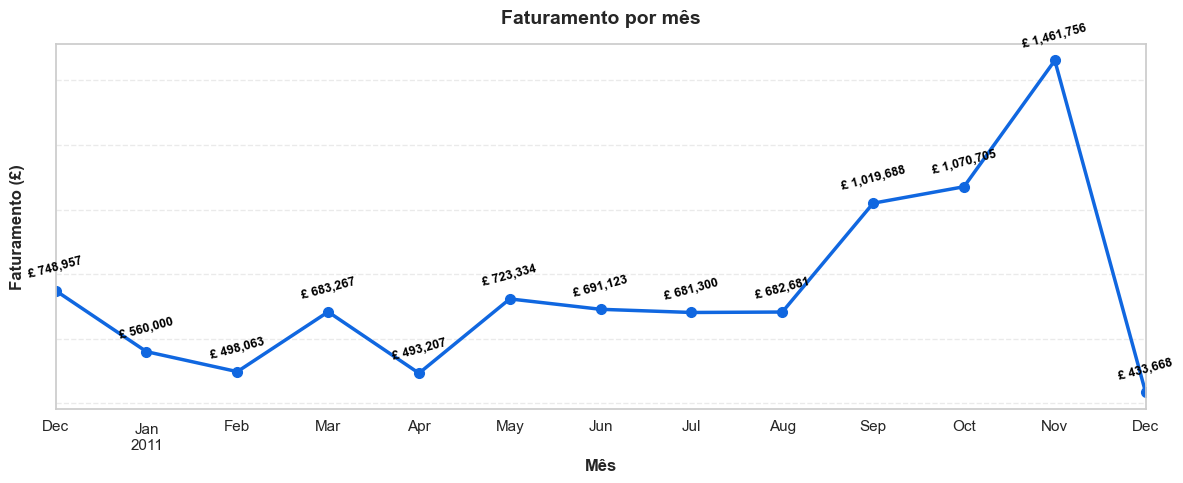

In [232]:
# Cria um gráfico do faturamento mensal.
ax = faturamento_mensal.plot(
    kind="line", 
    figsize=(12, 5), 
    marker="o", 
    color="#1067E0", 
    linewidth=2.5, 
    markersize=7
    )

# Adiciona os valores em cada ponto
for x, y in zip(faturamento_mensal.index, faturamento_mensal.values):
    ax.annotate(
        f"£ {y:,.0f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9,
        fontweight='bold',
        color="black", 
        rotation=15
    )

# Remove os números do eixo Y
ax.tick_params(axis="y", labelleft=False)

# Deixa apenas as linhas horizontais da grade
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.grid(axis="x", visible=False)

plt.title("Faturamento por mês", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Mês", fontweight='bold')
plt.ylabel("Faturamento (£)", fontweight='bold', labelpad=22)
plt.tight_layout()

plt.savefig('Imagens/01_Faturamento_Mês.png', bbox_inches='tight')
plt.show()

In [233]:
# Cria uma cópia da base original para realizar o tratamento.
df_tratado = df.copy()

# Remove as faturas canceladas.
# No dataset, os cancelamentos são identificados pelo InvoiceNo iniciado por "C".
df_tratado = df_tratado[
    ~df_tratado["InvoiceNo"].str.startswith("C")
]

# Mantém somente registros com quantidade positiva.
df_tratado = df_tratado[df_tratado["Quantity"] > 0]

# Mantém somente registros com preço unitário maior que zero.
df_tratado = df_tratado[df_tratado["UnitPrice"] > 0]

# Remove registros duplicados para evitar que uma venda seja contabilizada mais de uma vez.
df_tratado = df_tratado.drop_duplicates()

# Recalcula o faturamento depois do tratamento.
df_tratado["TotalPrice"] = (
    df_tratado["Quantity"] * df_tratado["UnitPrice"]
)

print("Registros após o tratamento:", len(df_tratado))

Registros após o tratamento: 524878


In [234]:
display(df_tratado)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,2011-12
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011-12
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011-12
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011-12


In [235]:
# Remove somente os registros sem CustomerID para a análise de clientes.
# Esses registros podem continuar sendo utilizados em análises gerais de vendas.
df_clientes = df_tratado.dropna(subset=["CustomerID"]).copy()

print("Registros para análise de clientes:", len(df_clientes))
print("Quantidade de clientes:", df_clientes["CustomerID"].nunique())

Registros para análise de clientes: 392692
Quantidade de clientes: 4338


#### Construção do RFM

RFM representa:

- *Recency:* tempo desde a última compra.
- *Frequency:* quantidade de compras/faturas diferentes.
- *Monetary:* valor total gasto pelo cliente.


In [236]:
# Define como referência o dia seguinte à última data disponível.
# Assim, a recência é calculada em dias a partir de uma mesma data de referência.
data_referencia = (df_clientes["InvoiceDate"].max() + pd.Timedelta(days=1))

# Calcula a data da última compra de cada cliente.
ultima_compra = df_clientes.groupby("CustomerID")["InvoiceDate"].max()

# Calcula a Recency em dias.
recency = (data_referencia - ultima_compra).dt.days

# Conta quantas faturas diferentes cada cliente possui.
frequency = df_clientes.groupby("CustomerID")["InvoiceNo"].nunique()

# Soma o valor total gasto por cada cliente.
monetary = df_clientes.groupby("CustomerID")["TotalPrice"].sum()

# Junta os três indicadores em uma única tabela.
rfm = pd.DataFrame({
    "Recency": recency,
    "Frequency": frequency,
    "Monetary": monetary
})

display(rfm.head(15))

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
12352.0,36,8,2506.04
12353.0,204,1,89.00
12354.0,232,1,1079.40
12355.0,214,1,459.40


In [237]:
# Mostra estatísticas do RFM como média, mediana, mínimo e máximo.
display(rfm.describe())

# Mostra especificamente as medianas dos três indicadores do RFM.
display(rfm.median().to_frame("Mediana"))

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


,Mediana
Recency,51.00
Frequency,2.00
Monetary,668.57


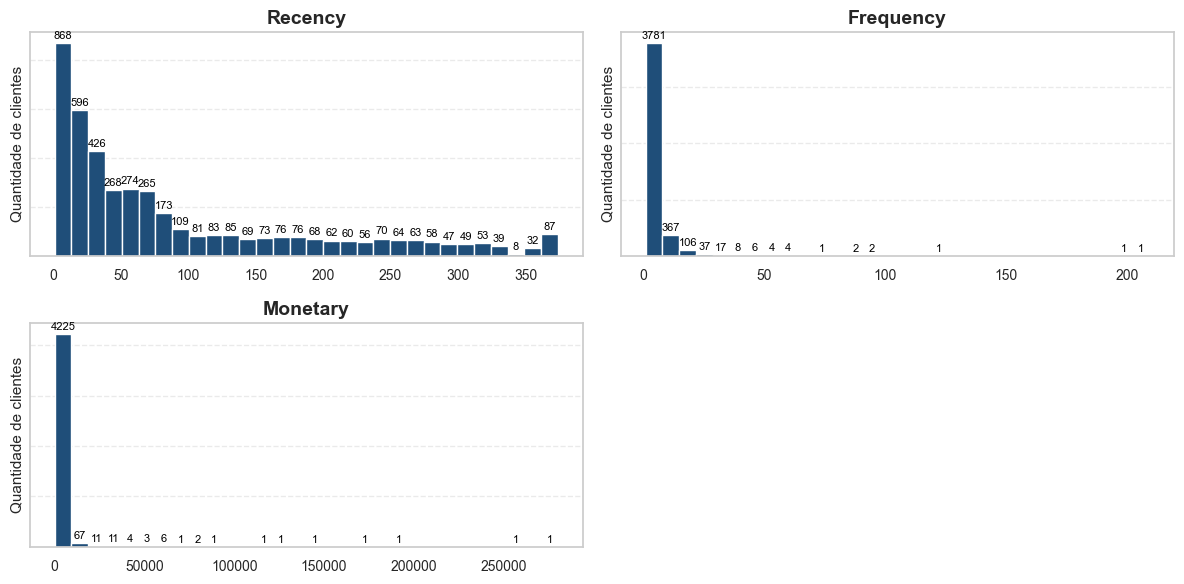

In [240]:
# Cria os histogramas dos indicadores RFM
ax = rfm.hist(
    figsize=(12, 6),
    bins=30,
    color="#1F4E79",
    edgecolor="white"
)

# Ajusta cada gráfico individualmente
for eixo in ax.flatten():

    # Título de cada gráfico
    eixo.set_title(
        eixo.get_title(),
        fontsize=14,
        fontweight="bold"
    )

    # Nome dos eixos
    eixo.set_ylabel("Quantidade de clientes", fontsize=11)

    # Mantém apenas a grade horizontal
    eixo.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    # Remove a grade vertical
    eixo.grid(
        axis="x",
        visible=False
    )

    # Parametros do eixo y
    eixo.tick_params(axis="y", labelleft=False)

    # Parametros do eixo x
    eixo.tick_params(axis="x", labelsize=10)

    # Adiciona rótulos no topo das barras
    for barra in eixo.patches:
        altura = barra.get_height()

        # Só mostra o rótulo se houver clientes naquela barra
        if altura > 0:
            eixo.annotate(
                f"{int(altura)}",
                (barra.get_x() + barra.get_width() / 2, altura),
                textcoords="offset points",
                xytext=(0, 3),
                ha="center",
                fontsize=8,
                color="black"
            )

plt.tight_layout()

plt.savefig('Imagens/02_Histogramas_indicadores_RFM.png', bbox_inches='tight')
plt.show()

In [142]:
# Os indicadores RFM podem apresentar valores muito diferentes entre os clientes. 
# A transformação logarítmica reduz o efeito de valores extremos antes da padronização.

# Aplica log(1 + valor) aos indicadores RFM.
# O log1p permite realizar a transformação de forma segura para valores iguais a zero.
rfm_log = np.log1p(rfm)

display(rfm_log.head())

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,5.789960,0.693147,11.253955
12347.0,1.098612,2.079442,8.368925
12348.0,4.330733,1.609438,7.494564
12349.0,2.995732,0.693147,7.472245
12350.0,5.739793,0.693147,5.815324


In [143]:
# Cria o objeto responsável pela padronização.
scaler = StandardScaler()

# Padroniza Recency, Frequency e Monetary.
# Isso coloca as variáveis em uma escala comparável para o K-Means.
rfm_scaled = scaler.fit_transform(rfm_log)

# Mostra as primeiras linhas dos dados padronizados.
rfm_scaled[:5]

array([[ 1.46199281, -0.95521426,  3.7077163 ],
       [-2.03873442,  1.07442519,  1.41490344],
       [ 0.37310424,  0.38630445,  0.72002428],
       [-0.62308592, -0.95521426,  0.70228691],
       [ 1.42455753, -0.95521426, -0.61451388]])

### Teste de diferentes quantidades de clusters

Serão testados valores de K entre 2 e 10.

- **Inertia:** utilizada no método do cotovelo.
- **Silhouette Score:** quanto maior, melhor.
- **Davies-Bouldin Score:** quanto menor, melhor.


In [144]:
# Lista que armazenará os resultados de cada valor de K.
resultados = []

# Testa K de 2 até 10 clusters.
for k in range(2, 11):

    # Cria o modelo K-Means com o número de clusters atual.
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    # Treina o modelo e obtém o cluster de cada cliente.
    labels = kmeans.fit_predict(rfm_scaled)

    # Calcula as métricas de avaliação.
    inertia = kmeans.inertia_
    silhouette = silhouette_score(rfm_scaled, labels)
    davies = davies_bouldin_score(rfm_scaled, labels)

    # Armazena os resultados.
    resultados.append({
        "K": k,
        "Inertia": inertia,
        "Silhouette": silhouette,
        "Davies_Bouldin": davies
    })

# Converte os resultados em DataFrame para facilitar a análise.
avaliacao = pd.DataFrame(resultados)

display(avaliacao)

,K,Inertia,Silhouette,Davies_Bouldin
0,2,6483.589425,0.432827,0.892499
1,3,4869.488629,0.336517,1.048336
2,4,3938.603205,0.337335,1.010579
3,5,3296.708708,0.316200,0.987779
4,6,2855.525596,0.312802,1.015594
5,7,2548.820245,0.309186,0.982334
6,8,2336.341054,0.303275,0.989165
7,9,2156.005673,0.281085,1.019266
8,10,2000.573165,0.278127,1.023669


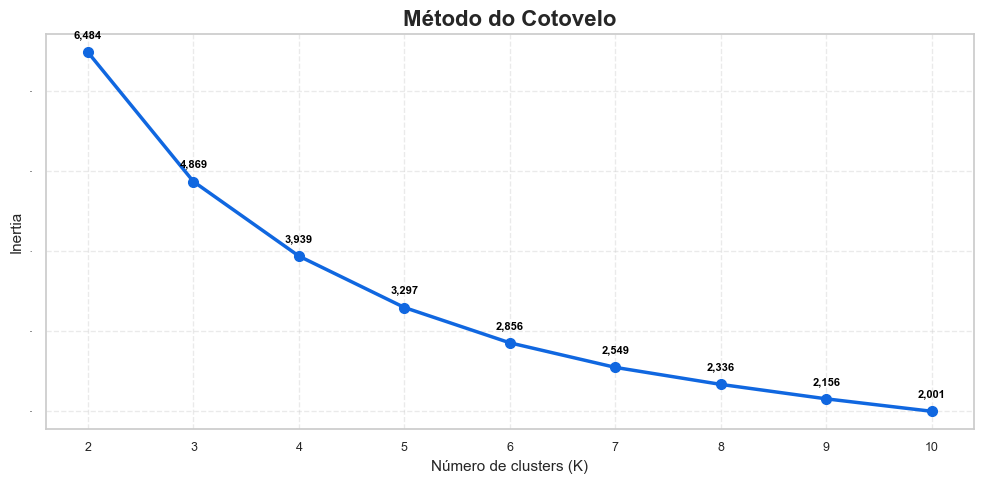

In [241]:
# Cria o gráfico da Inertia para auxiliar na escolha de K.
plt.figure(figsize=(10, 5))

ax = plt.gca()

ax.plot(
    avaliacao["K"],
    avaliacao["Inertia"],
    marker="o",
    color="#1067E0",
    linewidth=2.5,
    markersize=7
)

# Título
plt.title(
    "Método do Cotovelo",
    fontsize=16,
    fontweight="bold"
)

# Nomes dos eixos
plt.xlabel(
    "Número de clusters (K)",
    fontsize=11
)

plt.ylabel(
    "Inertia",
    fontsize=11
)

# Adiciona os valores nos pontos
for x, y in zip(avaliacao["K"], avaliacao["Inertia"]):
    ax.annotate(
        f"{y:,.0f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=8,
        color="black",
        fontweight='bold'
    )

# Grade horizontal
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# Remove a grade vertical
ax.grid(
    axis="x",
    linestyle="--",
        alpha=0.4
)

# Diminui o tamanho dos números dos eixos
ax.tick_params(
    axis="x",
    labelsize=9
)

ax.tick_params(
    axis="y",
    labelsize=False
)

plt.tight_layout()

plt.savefig('Imagens/03_Método_Cotovelo.png', bbox_inches='tight')
plt.show()

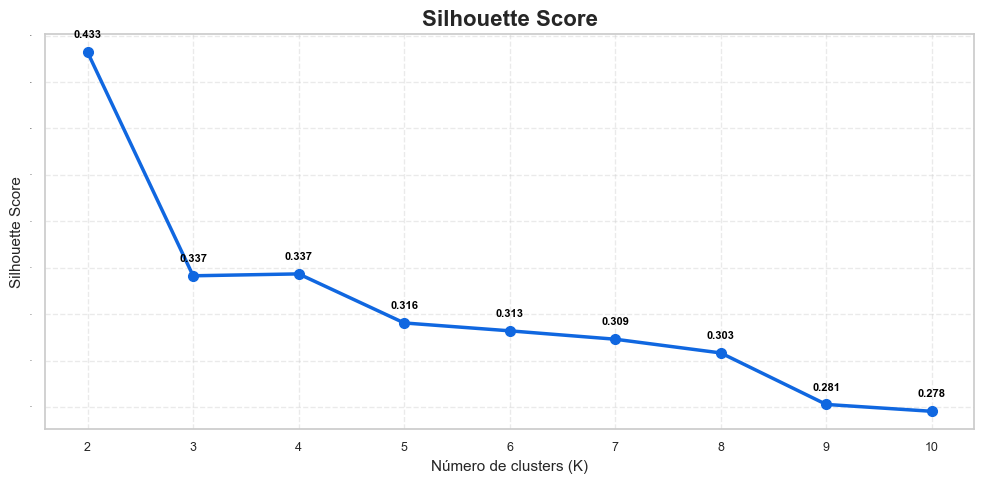

In [242]:
# Cria o gráfico do Silhouette Score para os diferentes valores de K.
plt.figure(figsize=(10, 5))

ax = plt.gca()

ax.plot(
    avaliacao["K"],
    avaliacao["Silhouette"],
    marker="o",
    color="#1067E0",
    linewidth=2.5,
    markersize=7
)

# Título
plt.title(
    "Silhouette Score",
    fontsize=16,
    fontweight="bold"
)

# Nomes dos eixos
plt.xlabel(
    "Número de clusters (K)",
    fontsize=11
)

plt.ylabel(
    "Silhouette Score",
    fontsize=11
)

# Adiciona os valores nos pontos
for x, y in zip(avaliacao["K"], avaliacao["Silhouette"]):
    ax.annotate(
        f"{y:.3f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=8,
        color="black",
        fontweight='bold'
    )

# Grade horizontal
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# Remove a grade vertical
ax.grid(
    axis="x",
    linestyle="--",
        alpha=0.4
)

# Diminui o tamanho dos números dos eixos
ax.tick_params(
    axis="x",
    labelsize=9
)

ax.tick_params(
    axis="y",
    labelsize=False
)

plt.tight_layout()

plt.savefig('Imagens/04_Silhouette_Score.png', bbox_inches='tight')
plt.show()

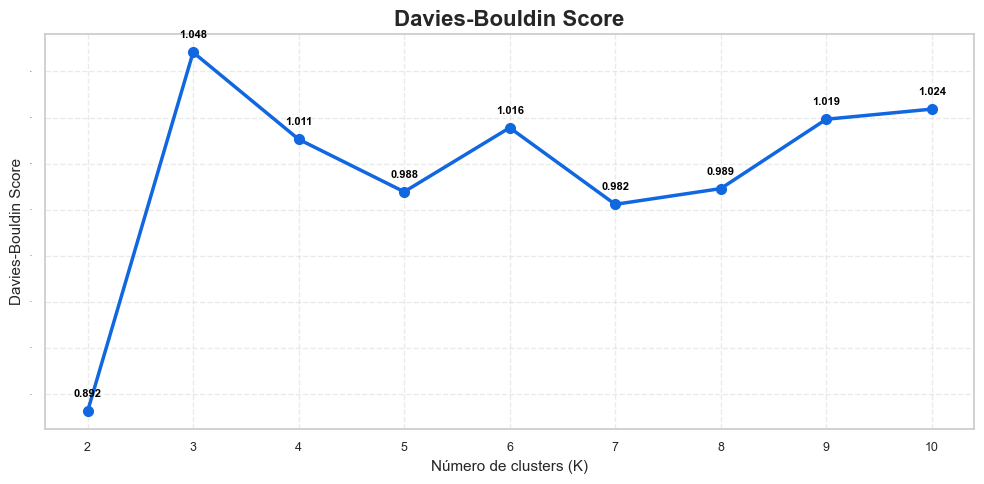

In [243]:
# Cria o gráfico do Davies-Bouldin Score para os diferentes valores de K.
plt.figure(figsize=(10, 5))

ax = plt.gca()

ax.plot(
    avaliacao["K"],
    avaliacao["Davies_Bouldin"],
    marker="o",
    color="#1067E0",
    linewidth=2.5,
    markersize=7
)

# Título
plt.title(
    "Davies-Bouldin Score",
    fontsize=16,
    fontweight="bold"
)

# Nomes dos eixos
plt.xlabel(
    "Número de clusters (K)",
    fontsize=11
)

plt.ylabel(
    "Davies-Bouldin Score",
    fontsize=11
)

# Adiciona os valores nos pontos
for x, y in zip(avaliacao["K"], avaliacao["Davies_Bouldin"]):
    ax.annotate(
        f"{y:.3f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=8,
        color="black",
        fontweight='bold'
    )

# Grade horizontal
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# Remove a grade vertical
ax.grid(
    axis="x",
    linestyle="--",
        alpha=0.4
)

# Diminui o tamanho dos números dos eixos
ax.tick_params(
    axis="x",
    labelsize=9
)

ax.tick_params(
    axis="y",
    labelsize=False
)

plt.tight_layout()

plt.savefig('Imagens/05_Davies-Bouldin_Score.png', bbox_inches='tight')
plt.show()

In [173]:
'''Foi escolhido K = 2 porque apresentou o maior Silhouette Score (0,432827) e 
o menor Davies-Bouldin Score (0,892499) entre os valores de K testados. Isso 
indica que, nesse conjunto de dados, a divisão em dois clusters apresentou melhor 
separação e maior coerência entre os grupos. A inércia também foi analisada por meio 
do método do cotovelo, mas não deve ser utilizada isoladamente para definir o número de clusters.'''

# Define o número de clusters escolhido para o modelo final.
# A análise preliminar indicou K=2 como ponto de partida.
K_ESCOLHIDO = 2

In [246]:
# Cria o modelo K-Means final com o K escolhido.
kmeans = KMeans(
    n_clusters=K_ESCOLHIDO,
    random_state=45,
    n_init=20
)

# Treina o modelo e atribui um cluster a cada cliente.
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

# Exibe as primeiras linhas com o cluster atribuído.
display(rfm.head())

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,1
12347.0,2,7,4310.00,1
12348.0,75,4,1797.24,1
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,0


In [247]:
# Avaliação do Modelo

# Calcula o Silhouette Score do modelo final.
silhouette_final = silhouette_score(
    rfm_scaled,
    rfm["Cluster"]
)

# Calcula o Davies-Bouldin Score do modelo final.
davies_final = davies_bouldin_score(
    rfm_scaled,
    rfm["Cluster"]
)

print("Silhouette Score:", round(silhouette_final, 4))
print("Davies-Bouldin Score:", round(davies_final, 4))


Silhouette Score: 0.4328
Davies-Bouldin Score: 0.8925


Cluster
0    2671
1    1667
Name: count, dtype: int64

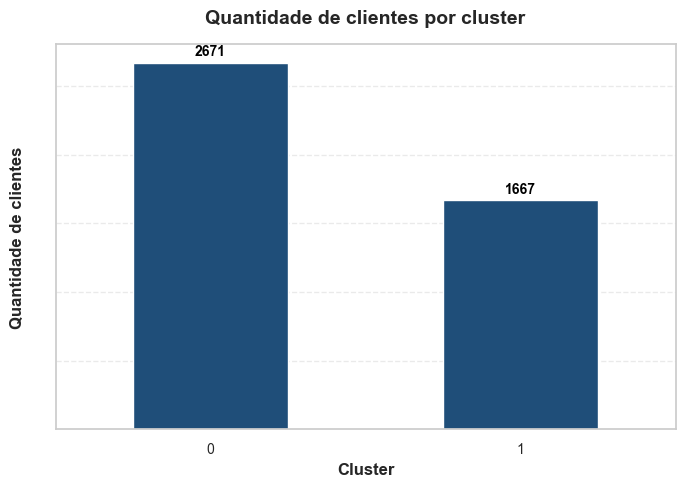

In [248]:
# Conta quantos clientes pertencem a cada cluster.
clientes_cluster = (
    rfm["Cluster"]
    .value_counts()
    .sort_index()
)

display(clientes_cluster)

# Cria um gráfico com a quantidade de clientes por cluster.
ax = clientes_cluster.plot(kind="bar", figsize=(8, 5), color="#1F4E79")

# Adiciona os valores em cada ponto
for x, y in zip(clientes_cluster.index, clientes_cluster.values):
    ax.annotate(
        f"{y:.0f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 5),
        ha="center",
        fontsize=10,
        fontweight='bold',
        color="black", 
    )

# Remove os números do eixo Y
ax.tick_params(axis="y", labelleft=False)
ax.tick_params(axis="x", rotation=0, labelsize=10)

# Deixa apenas as linhas horizontais da grade
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.grid(axis="x", visible=False)

plt.title("Quantidade de clientes por cluster", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Cluster",  fontweight='bold')
plt.ylabel("Quantidade de clientes", fontweight='bold', labelpad=22)

plt.savefig('Imagens/06_Quantidade_Clientes_Cluster.png', bbox_inches='tight')
plt.show()

In [192]:
# Calcula indicadores médios e totais para descrever cada cluster.
perfil_clusters = (
    rfm.groupby("Cluster")
       .agg(
           Clientes=("Cluster", "size"),
           Recencia_Media=("Recency", "mean"),
           Frequencia_Media=("Frequency", "mean"),
           Valor_Medio=("Monetary", "mean"),
           Faturamento_Total=("Monetary", "sum")
       )
       .round(2)
)

# Calcula a participação de cada cluster no faturamento total.
perfil_clusters["Participacao_Faturamento_%"] = (
    perfil_clusters["Faturamento_Total"]
    / perfil_clusters["Faturamento_Total"].sum()
    * 100
).round(2)

display(perfil_clusters)

,Clientes,Recencia_Media,Frequencia_Media,Valor_Medio,Faturamento_Total,Participacao_Faturamento_%
Cluster,,,,,,
0,2671,134.12,1.67,495.43,1323290.32,14.89
1,1667,25.91,8.44,4537.44,7563918.57,85.11


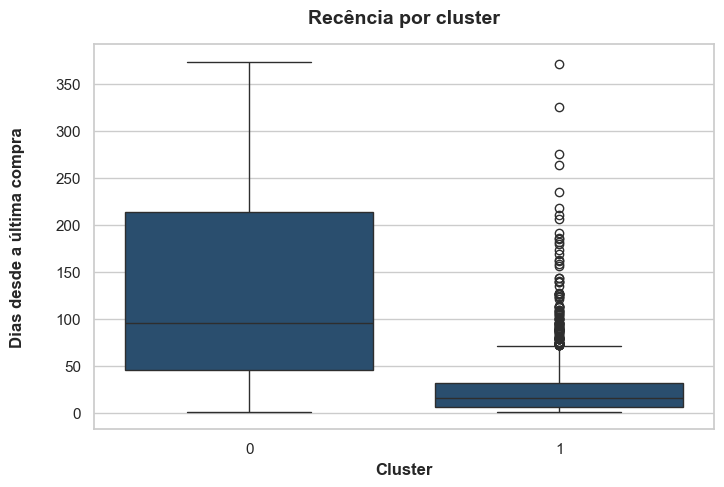

In [249]:
# Mostra a distribuição da Recency em cada cluster.
plt.figure(figsize=(8, 5))
sns.boxplot(data=rfm, x="Cluster", y="Recency", color="#1F4E79")

plt.title("Recência por cluster", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Cluster", fontweight='bold')
plt.ylabel("Dias desde a última compra", fontweight='bold', labelpad=22)

plt.savefig('Imagens/07_Recência_Cluster.png', bbox_inches='tight')
plt.show()

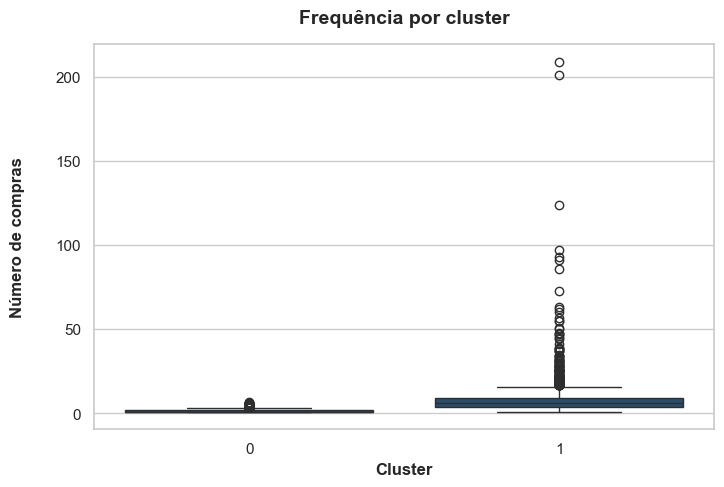

In [250]:
# Mostra a distribuição da Frequency em cada cluster.
plt.figure(figsize=(8, 5))
sns.boxplot(data=rfm, x="Cluster", y="Frequency", color="#1F4E79")

plt.title("Frequência por cluster", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Cluster", fontweight='bold')
plt.ylabel("Número de compras", fontweight='bold', labelpad=22)

plt.savefig('Imagens/08_Frequência_Cluster.png', bbox_inches='tight')
plt.show()

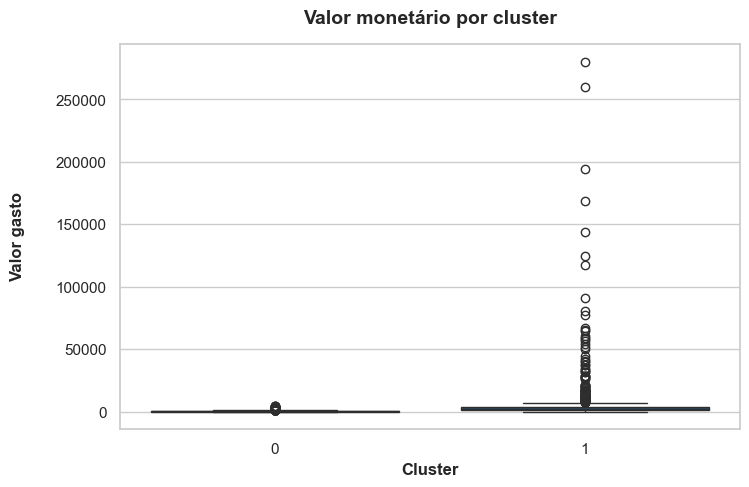

In [251]:
# Mostra a distribuição do valor Monetary em cada cluster.
plt.figure(figsize=(8, 5))
sns.boxplot(data=rfm, x="Cluster", y="Monetary", color="#1F4E79")

plt.title("Valor monetário por cluster", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Cluster", fontweight='bold')
plt.ylabel("Valor gasto", fontweight='bold', labelpad=22)

plt.savefig('Imagens/09_Valor_Monetário_Cluster.png', bbox_inches='tight')
plt.show()

In [252]:
# Junta o cluster de cada cliente à base de transações.
df_analise_clusters = df_clientes.merge(
    rfm[["Cluster"]],
    left_on="CustomerID",
    right_index=True,
    how="inner"
)

display(df_analise_clusters.head(15))

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month,Cluster
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,1
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.30,2010-12,1
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.50,2010-12,1
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10,2010-12,1
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10,2010-12,1
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08,2010-12,1


In [253]:
# Soma a quantidade vendida de cada produto dentro de cada cluster.
produtos_cluster = (
    df_analise_clusters
    .groupby(["Cluster", "StockCode", "Description"])["Quantity"]
    .sum()
    .reset_index()
)

# Ordena os produtos do maior para o menor volume dentro de cada cluster.
produtos_cluster = produtos_cluster.sort_values(
    ["Cluster", "Quantity"],
    ascending=[True, False]
)

display(produtos_cluster.head(15))

,Cluster,StockCode,Description,Quantity
2568,0,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,10709
9,0,15036,ASSORTED COLOURS SILK FAN,6704
35,0,17003,BROCADE RING PURSE,6061
39,0,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,5666
2655,0,84879,ASSORTED COLOUR BIRD ORNAMENT,5190
342,0,21212,PACK OF 72 RETROSPOT CAKE CASES,5148
1004,0,22197,SMALL POPCORN HOLDER,5127
3323,0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,4494
3317,0,85099B,JUMBO BAG RED RETROSPOT,4226
1272,0,22492,MINI PAINT SET VINTAGE,4141


In [254]:
# Soma o faturamento por país dentro de cada cluster.
faturamento_pais_cluster = (
    df_analise_clusters
    .groupby(["Cluster", "Country"])["TotalPrice"]
    .sum()
    .reset_index()
    .sort_values(
        ["Cluster", "TotalPrice"],
        ascending=[True, False]
    )
)

display(faturamento_pais_cluster.head(15))

,Cluster,Country,TotalPrice
32,0,United Kingdom,1134956.553
13,0,Germany,33458.170
12,0,France,22256.110
29,0,Switzerland,16958.540
27,0,Spain,13400.110
6,0,Channel Islands,9423.960
24,0,Portugal,9284.780
17,0,Japan,9009.940
3,0,Belgium,7387.430
15,0,Israel,7215.840


In [255]:
# Ordena os clientes pelo valor total gasto.
top_clientes = (
    rfm.sort_values(
        "Monetary",
        ascending=False
    )
    .head(15)
)

# Exibe os 20 clientes com maior valor monetário.
display(top_clientes)

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
14646.0,2,73,280206.02,1
18102.0,1,60,259657.30,1
17450.0,8,46,194390.79,1
16446.0,1,2,168472.50,1
14911.0,1,201,143711.17,1
12415.0,24,21,124914.53,1
14156.0,10,55,117210.08,1
17511.0,3,31,91062.38,1
16029.0,39,63,80850.84,1


In [256]:
# Cria a pasta "Resultados" caso ela ainda não exista.
os.makedirs("Resultados", exist_ok=True)

# Salva a tabela RFM dos clientes.
rfm.to_csv(
    "resultados/rfm_clientes.csv",
    index=True
)

# Salva o perfil dos clusters.
perfil_clusters.to_csv(
    "resultados/perfil_clusters.csv",
    index=True
)

# Salva as métricas calculadas para cada valor de K.
avaliacao.to_csv(
    "resultados/avaliacao_clusters.csv",
    index=False
)

# Salva a base transacional com o cluster de cada cliente.
df_analise_clusters.to_csv(
    "resultados/clientes_com_clusters.csv",
    index=False
)

print("Arquivos exportados com sucesso para a pasta resultados.")

Arquivos exportados com sucesso para a pasta resultados.


### 33. Conclusão

Os dados do Online Retail foram analisados e tratados para remover registros que poderiam prejudicar a análise do comportamento de compra, como cancelamentos, quantidades inválidas, preços inválidos e duplicidades.

Após o tratamento, foi criada uma base específica de clientes e calculados os indicadores RFM: Recency, Frequency e Monetary.

Esses indicadores foram utilizados como características para a aplicação do algoritmo K-Means, permitindo agrupar clientes com comportamentos semelhantes.

A quantidade de clusters foi analisada por meio do método do cotovelo, Silhouette Score e Davies-Bouldin Score. Depois, os grupos foram analisados considerando quantidade de clientes, recência, frequência, valor monetário, faturamento, produtos e países.

Como o K-Means é um método de aprendizado não supervisionado, não é utilizada a acurácia tradicional de classificação. As métricas de avaliação utilizadas são Silhouette Score e Davies-Bouldin, complementadas pela interpretação dos perfis encontrados.